# Cross-sample alignment - two mouse kidney sections from Visium

This notebook aligns the IL3 query section to the fixed NL3
reference. It starts from the clustered AnnData and follows the
same visual sequence as the MERFISH mouse-brain tutorial:
pre-alignment, pseudo-image construction, S-LDDMM, and overlap
comparisons without and with cluster colors.

**Fixed-seed reproducibility.** This workflow uses seed `1000`. Launch Python with `PYTHONHASHSEED` set before kernel startup, then keep the documented input order, package versions and configuration fixed. Discrete labels/pairs are expected to match exactly; CUDA coordinates are compared with the documented numerical tolerance.

## Installation and input

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,tutorial]"
```

By default the notebook reads the output of the kidney clustering
notebook. Override it with:

```bash
export SPALIGNDE_KIDNEY_CLUSTERED_H5AD=/path/to/clustered_kidney.h5ad
```

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
import spAlignDE

WORKFLOW_SEED = 1000
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 8,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "legend.frameon": False,
})


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the spAlignDE repository")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_sample" / "kidney" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
default_path = OUTPUT_DIR / "kidney_IL3_NL3_joint_clustered.h5ad"
clustered_path = Path(
    os.environ.get("SPALIGNDE_KIDNEY_CLUSTERED_H5AD", default_path)
).expanduser().resolve()

adata = ad.read_h5ad(clustered_path)
spAlignDE.validate_cross_sample_anndata(adata)
QUERY = "IL3"
REFERENCE = "NL3"
COORDINATE_SCALE = 50.0
raw_spatial = np.asarray(adata.obsm["spatial"], dtype=float).copy()
adata_scaled = adata.copy()
adata_scaled.obsm["spatial"] = raw_spatial * COORDINATE_SCALE

print(adata)
print(adata.obs["sample_id"].value_counts().sort_index())
print("Internal coordinate scale:", COORDINATE_SCALE)

AnnData object with n_obs × n_vars = 6180 × 12697
    obs: 'sample', 'source_file', 'is_spatial_filtered', 'batch', 'sample_id', 'x', 'y', 'cluster_raw', 'cluster_refined', 'cluster'
    uns: 'combined_from', 'matrix_orientation_in_source', 'spAlignDE'
    obsm: 'spatial'
sample_id
IL3    2965
NL3    3215
Name: count, dtype: int64
Internal coordinate scale: 50.0


## Automatic shared-structure pre-alignment

The reported kidney benchmark estimates rotation, scale and translation automatically from the four fixed-seed shared spatial structures. Cluster-size weighting is enabled and reflection is disabled.

Using cluster-correspondence prealign with 4 shared clusters
{
  "scale": 0.827384511623123,
  "theta_deg": 0.5780923250631759,
  "translation_x": 319.2359667480548,
  "translation_y": 538.8383268161883,
  "det_R": 1.0,
  "R": [
    [
      0.9999491002718992,
      -0.010089443266070114
    ],
    [
      0.010089443266070095,
      0.9999491002718992
    ]
  ],
  "t": [
    319.2359667480548,
    538.8383268161883
  ],
  "prealign_method": "shared_cluster_weighted_procrustes",
  "transform_convention": "aligned = scale * source @ R.T + t",
  "source_sample": "IL3",
  "target_sample": "NL3",
  "cluster_col": "cluster",
  "n_shared_clusters": 4,
  "weighted_centroid_rmse": 143.73972475779937,
  "unweighted_centroid_rmse": 152.55997508092204,
  "allow_scaling": true,
  "allow_reflection": false,
  "weight_mode": "min_size",
  "min_cluster_size": 10
}
scale: 0.827384511623123
theta_deg: 0.5780923250631759
translation_x: 319.2359667480548
translation_y: 538.8383268161883
n_shared_clusters

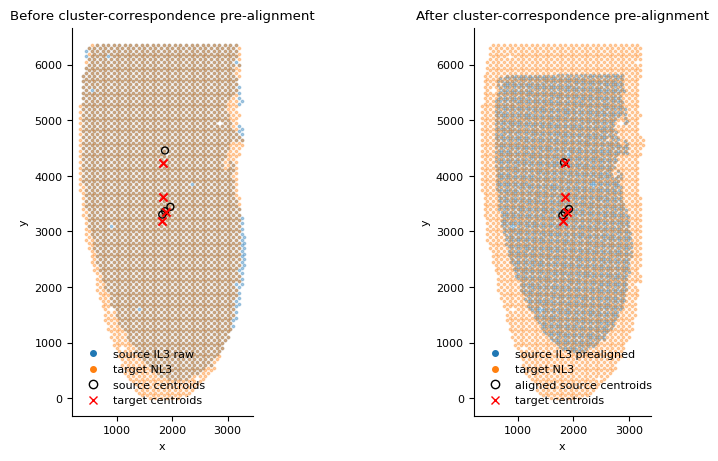

In [2]:
prealignment = spAlignDE.prealign_cross_sample(
    adata_scaled,
    query_sample=QUERY,
    reference_sample=REFERENCE,
    config=spAlignDE.PrealignmentConfig(
        allow_scaling=True,
        allow_reflection=False,
        use_cluster_size_weights=True,
        min_cluster_size=10,
    ),
)
for key in (
    "scale", "theta_deg", "translation_x", "translation_y", "n_shared_clusters", "weighted_centroid_rmse",
):
    print(f"{key}: {prealignment.params[key]}")
spAlignDE.plot_prealignment_result(
    prealignment,
    point_size=3.0,
    point_alpha=0.35,
    figsize=(8, 4.5),
)

## Convert spots to continuous pseudo-images

The four shared kidney domains define composition channels.
Density is retained for visualization but given zero optimization
weight, matching the original kidney analysis.

Shared cluster channels: 4
Pseudo-image shape: (5, 224, 224)
Shared grid: 224 x 224


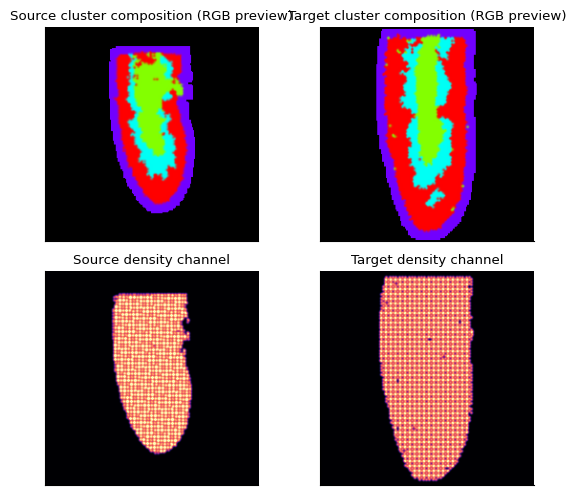

In [3]:
fields = spAlignDE.rasterize_cross_sample(
    prealignment.adata,
    query_sample=QUERY,
    reference_sample=REFERENCE,
    config=spAlignDE.RasterizationConfig(
        grid_spacing=30,
        grid_expand=1.05,
        blur_sigma=1,
        cluster_weight=1,
        density_weight=0,
    ),
)
print("Shared cluster channels:", len(fields.shared_clusters))
print("Pseudo-image shape:", fields.query_image.shape)
print("Shared grid:", len(fields.grid_y), "x", len(fields.grid_x))
spAlignDE.plot_rasterized_fields(fields, figsize=(6, 5))

## Shooting-based LDDMM refinement

This run uses the requested kidney parameters:
`a=500`, `nt=5`, `grid_step=250`, `lrM=50`, and `niter=5000`.
`minimum_momentum_lr` is also set to 50 so the requested momentum
learning rate is not replaced by the package default lower bound.

In [4]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
slddmm_config = spAlignDE.SLDDMMConfig(
    kernel_scale=500,
    kernel_power=2,
    velocity_expand=2,
    time_steps=5,
    velocity_grid_spacing=250,
    iterations=5000,
    momentum_lr=50,
    minimum_momentum_lr=50,
    restore_best_checkpoint=False,
    dtype="float32",
)
result = spAlignDE.run_slddmm_alignment(
    prealignment.adata,
    fields,
    config=slddmm_config,
    device=device,
    prealignment=prealignment,
    verbose=True,
    print_every=500,
)
print("Alignment summary (scaled-coordinate fit):")
for key, value in result.metrics.items():
    print(f"  {key}: {value}")

[LDDMM] start: niter=5000, nt=5, device=cuda:0, I_shape=(5, 224, 224), J_shape=(5, 224, 224)
[LDDMM] iter 1/5000 E=2.496034e+03 EM=2.496034e+03 ER=0.000000e+00


[LDDMM] iter 501/5000 E=4.759193e+03 EM=4.758954e+03 ER=2.390808e-01


[LDDMM] iter 1001/5000 E=4.599806e+03 EM=4.598909e+03 ER=8.963845e-01


[LDDMM] iter 1501/5000 E=4.496482e+03 EM=4.494772e+03 ER=1.709370e+00


[LDDMM] iter 2001/5000 E=4.426644e+03 EM=4.424100e+03 ER=2.543797e+00


...

[LDDMM] iter 3001/5000 E=4.312077e+03 EM=4.308131e+03 ER=3.946378e+00


[LDDMM] iter 3501/5000 E=4.240289e+03 EM=4.235557e+03 ER=4.731932e+00


[LDDMM] iter 4001/5000 E=4.198530e+03 EM=4.193016e+03 ER=5.514408e+00


[LDDMM] iter 4501/5000 E=4.171375e+03 EM=4.165320e+03 ER=6.054741e+00


[LDDMM] iter 5000/5000 E=4.144629e+03 EM=4.137910e+03 ER=6.719949e+00
[LDDMM] done in 71.9s. finalE=4.144629e+03
Alignment summary (scaled-coordinate fit):
  nearest_label_agreement_prealigned: 0.5689713322091062
  nearest_label_agreement_aligned: 0.6057335581787521
  nearest_label_agreement_gain: 0.036762225969645845
  elapsed_seconds: 71.86027908325195
  n_shared_clusters: 4
  device: cuda:0


### How to adapt rasterization and S-LDDMM parameters

First confirm that the global pre-alignment is anatomically plausible and that
the rasterized shared structures overlap. S-LDDMM should refine an already
credible initialization, not repair a wrong rotation, scale, reflection or
cluster correspondence.

- `grid_spacing` is the structural-image resolution. Smaller values preserve
  detail but increase memory and sensitivity to sparse sampling.
- `blur_sigma` is measured in raster pixels. Increase it for fragmented sparse
  fields; decrease it if adjacent thin structures merge.
- `density_weight` is useful when sampling density describes tissue shape. It
  can be reduced or set to zero for approximately regular spot grids.
- `kernel_scale` is legacy `a`. Increasing it makes deformation smoother and
  more global; decreasing it permits more local bending and raises overfitting
  risk.
- `velocity_grid_spacing` is legacy `grid_step`. Decreasing it creates a denser
  velocity field with more memory/runtime and local flexibility; increasing it
  produces a coarser, more regularized field. Tune it together with `a`.
- `time_steps` (`nt`) controls integration accuracy rather than deformation
  amplitude. `iterations` (`niter`) controls optimization duration.
- Increase `momentum_lr` (`lrM`) only when energy decreases stably but too
  slowly; reduce it if energy oscillates, becomes non-finite or the warp is
  implausibly local.

All distance-valued settings use the coordinates passed to this stage. Do not
copy `a`, `grid_step`, raster spacing or translations between differently
scaled datasets without rescaling and rechecking the velocity-grid dimensions.

## Return to the original kidney coordinate scale

S-LDDMM is fitted after multiplying the compact array coordinates
by 50. The standardized output columns are divided by the same
factor, and `adata.obsm["spatial"]` is restored before plotting and
saving.

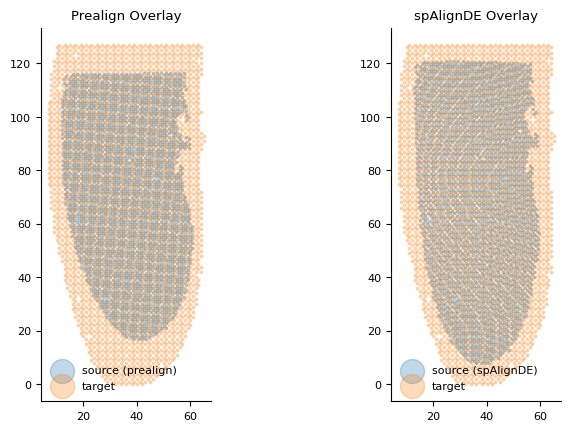

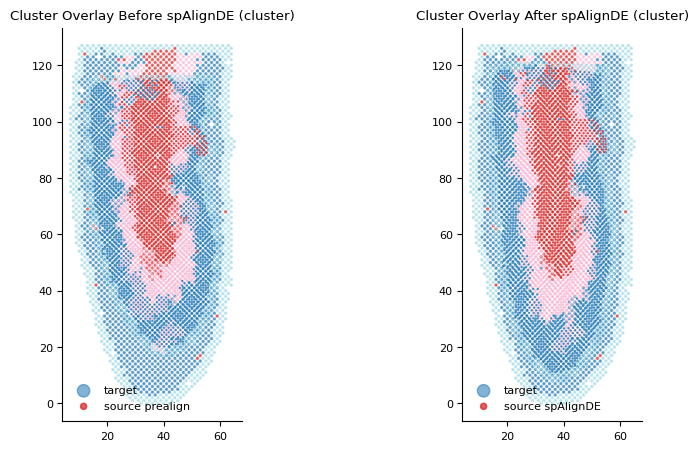

,cluster,n_cells,prealign_match_rate,lddmm_match_rate,prealign_mean_nn_dist,lddmm_mean_nn_dist,match_rate_gain
0,0,1170,0.698291,0.743590,27.163124,27.299686,0.045299
1,1,729,0.710562,0.742112,27.334317,27.027325,0.031550
2,2,536,0.654851,0.718284,26.714719,27.057641,0.063433
3,3,530,0.001887,0.000000,27.212834,25.773629,-0.001887


In [5]:
output_columns = ["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]
result.adata.obs.loc[:, output_columns] = (
    result.adata.obs.loc[:, output_columns].to_numpy(dtype=float)
    / COORDINATE_SCALE
)
result.adata.obsm["spatial"] = raw_spatial
result.adata.uns["spAlignDE"]["cross_sample_alignment"][
    "internal_coordinate_scale"
] = COORDINATE_SCALE

spAlignDE.plot_alignment_result(
    result,
    point_size=3.0,
    alpha=0.28,
    figsize=(7, 4.2),
)
spAlignDE.plot_cluster_alignment_result(
    result,
    point_size=2.2,
    target_alpha=0.55,
    source_alpha=0.75,
    figsize=(8, 4.4),
)
result.cluster_performance.sort_values("cluster")

## Save the aligned kidney AnnData

The fixed NL3 coordinates are unchanged. The IL3 output coordinates
are stored in `x_prealigned`, `y_prealigned`, `x_aligned`, and
`y_aligned`, all in the original array-coordinate scale.

In [6]:
aligned_path = OUTPUT_DIR / "kidney_IL3_to_NL3_aligned.h5ad"
result.adata.write_h5ad(aligned_path)

sample = result.adata.obs["sample_id"].astype(str)
reference_mask = sample.eq(REFERENCE).to_numpy()
reference_output = result.adata.obs.loc[
    reference_mask, output_columns
].to_numpy(dtype=float)
assert np.allclose(reference_output[:, :2], raw_spatial[reference_mask])
assert np.allclose(reference_output[:, 2:], raw_spatial[reference_mask])

print("Saved:", aligned_path.relative_to(PROJECT_ROOT))
print(result.adata.obs.loc[sample.eq(QUERY), output_columns].head())
print("Reference coordinates verified unchanged.")

Saved: tutorials/cross_sample/kidney/output/kidney_IL3_to_NL3_aligned.h5ad
                                                    x_prealigned  \
obs_name                                                           
AAACAAGTATCTCCCA-1|IL3_gene_expression_genes_x_...     46.900359   
AAACAGAGCGACTCCT-1|IL3_gene_expression_genes_x_...     17.182815   
AAACAGCTTTCAGAAG-1|IL3_gene_expression_genes_x_...     41.885312   
AAACAGGGTCTATATT-1|IL3_gene_expression_genes_x_...     45.161290   
AAACATTTCCCGGATT-1|IL3_gene_expression_genes_x_...     56.042864   

                                                    y_prealigned  x_aligned  \
obs_name                                                                      
AAACAAGTATCTCCCA-1|IL3_gene_expression_genes_x_...     95.583084  46.962891   
AAACAGAGCGACTCCT-1|IL3_gene_expression_genes_x_...     88.663822  18.776552   
AAACAGCTTTCAGAAG-1|IL3_gene_expression_genes_x_...     18.581806  39.219055   
AAACAGGGTCTATATT-1|IL3_gene_expression_genes_x_...   